# Análisis de Componentes Principales (PCA)

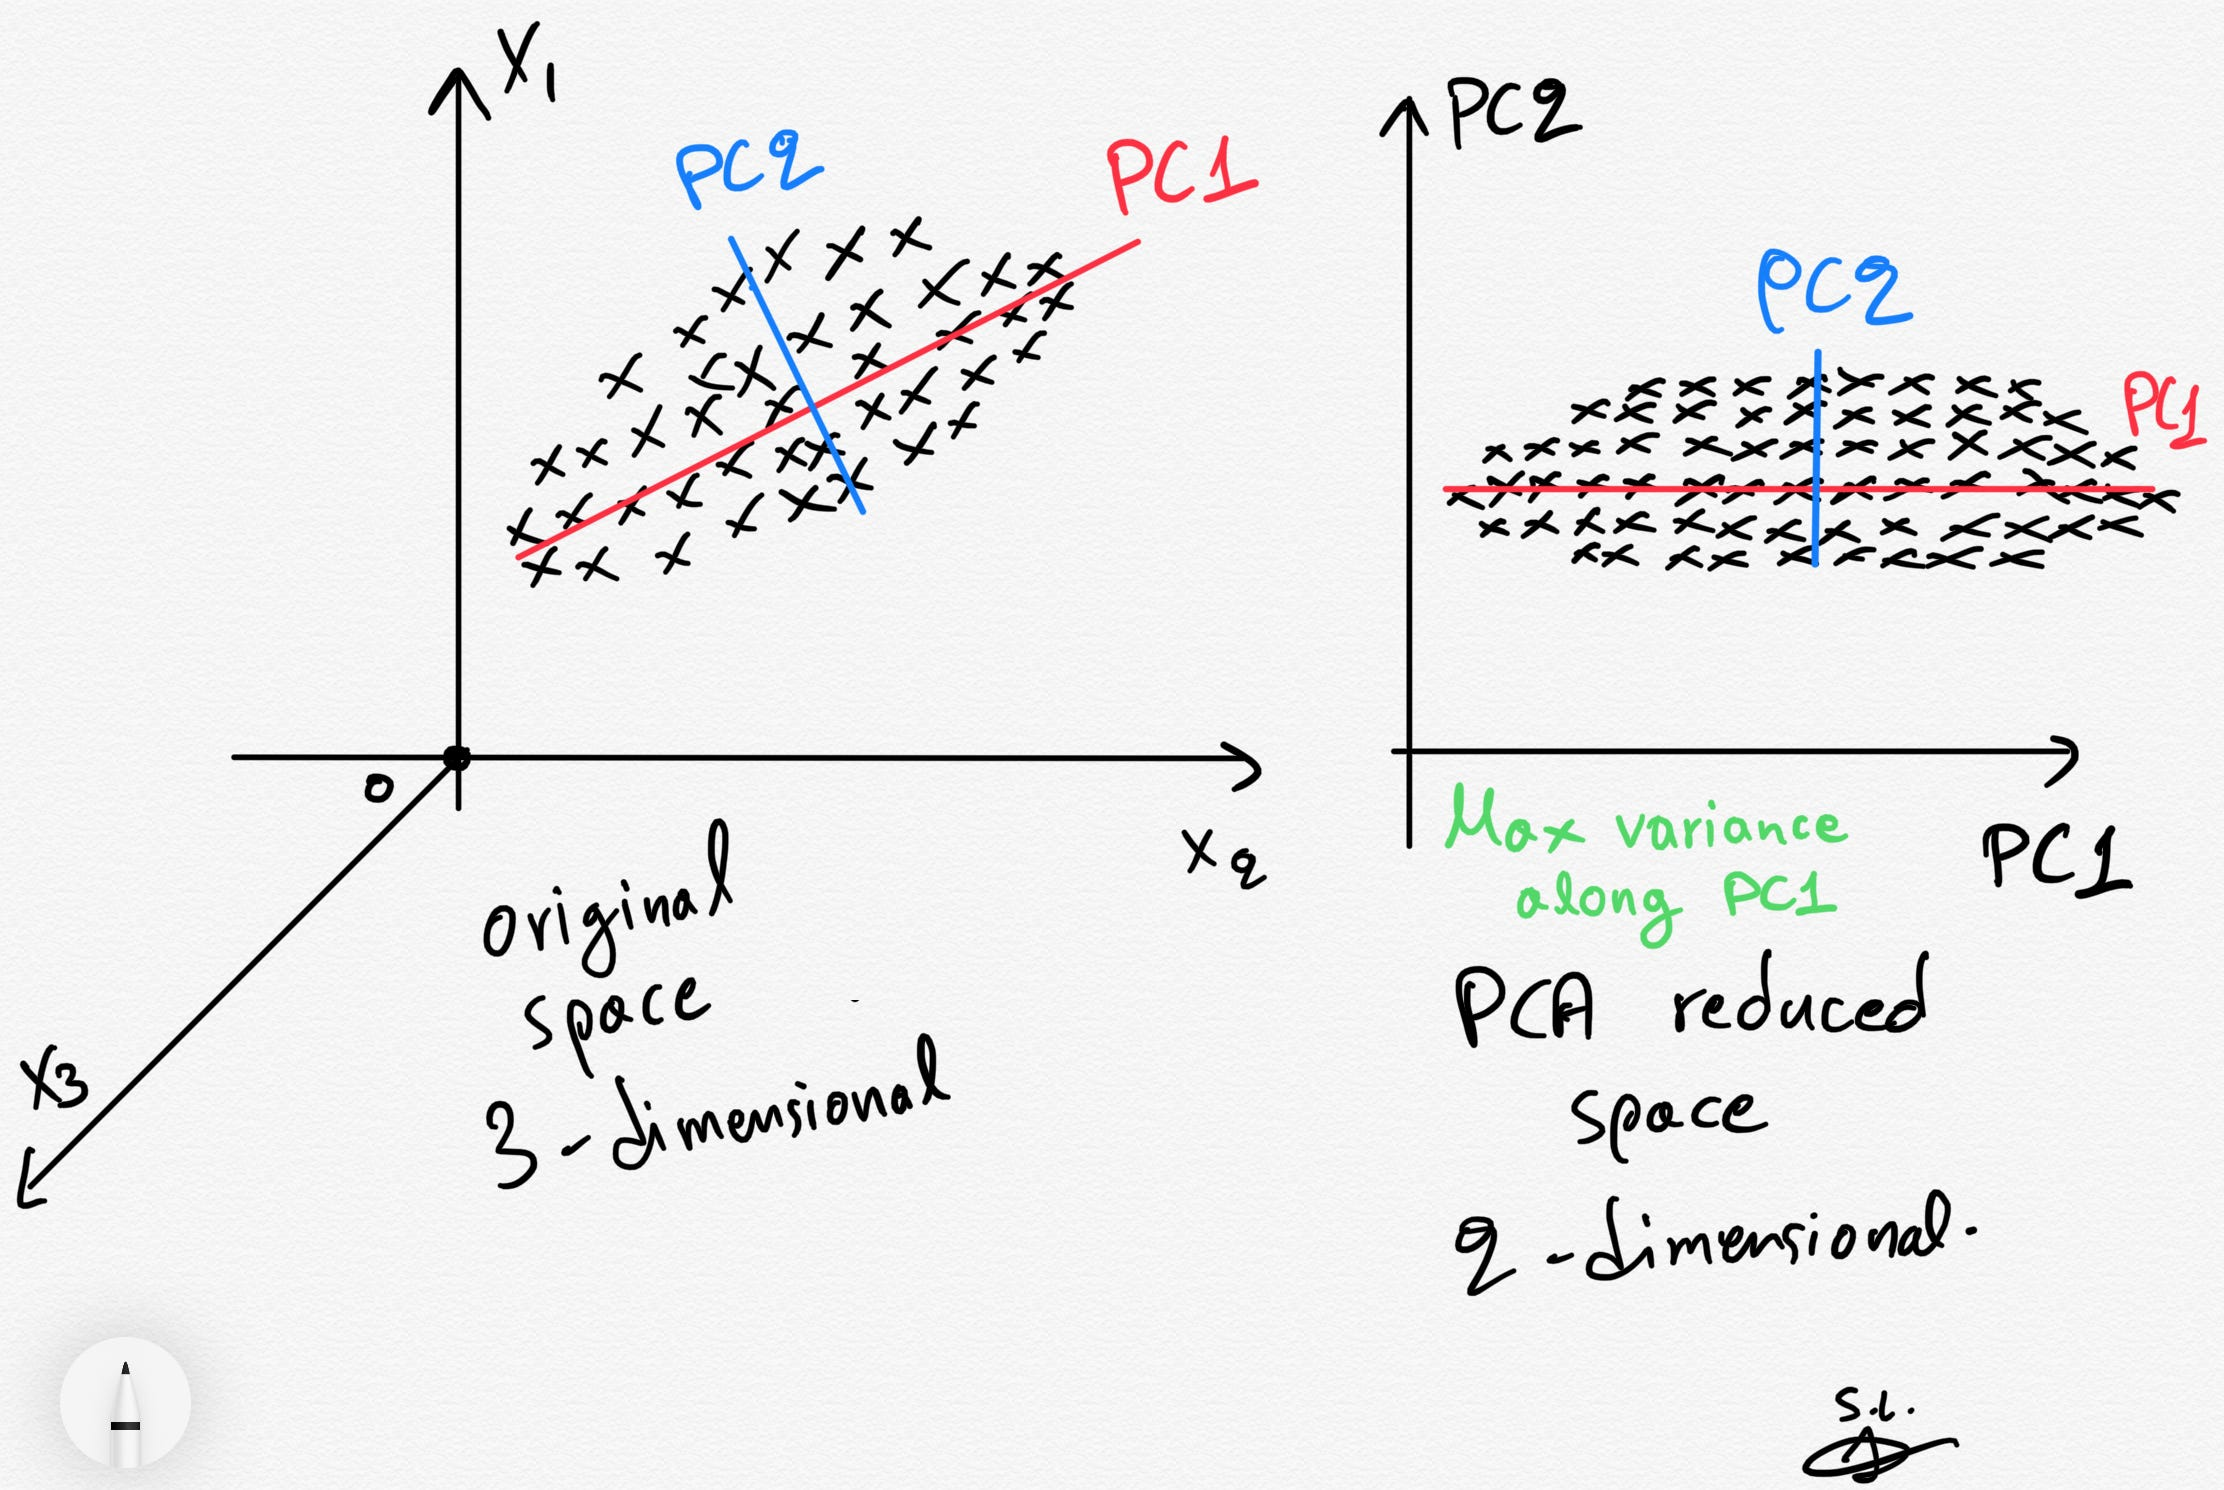

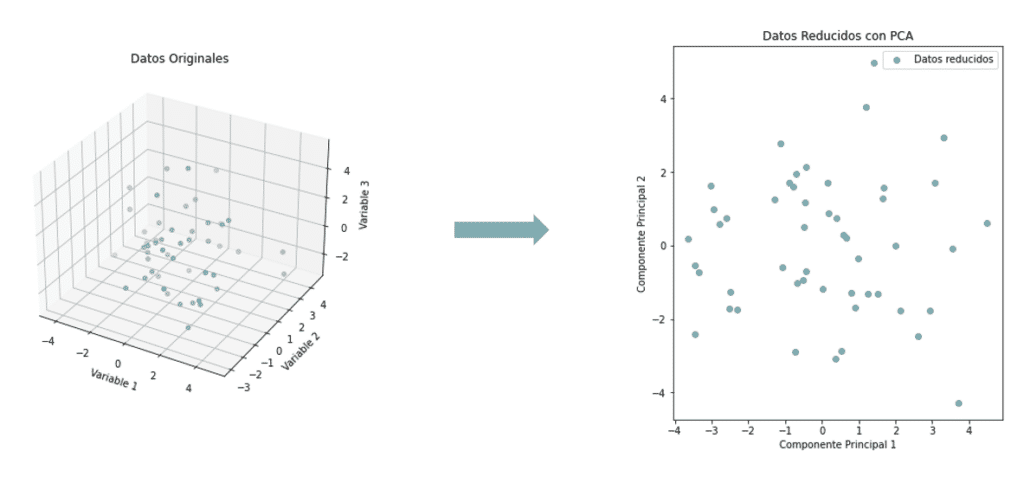

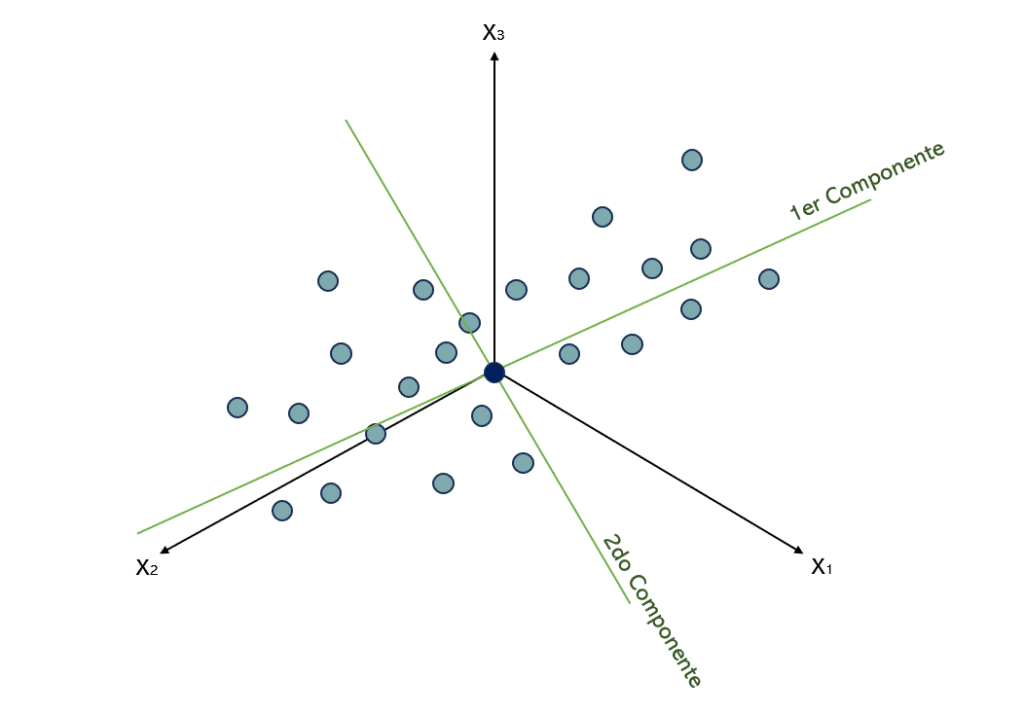

<font color='brown'>
<strong>Autovector 1</strong> = Dirección donde los datos se ESTIRAN más (PC1)<br>
<strong>Autovalor 1</strong> = Qué TAN estirados están</font>

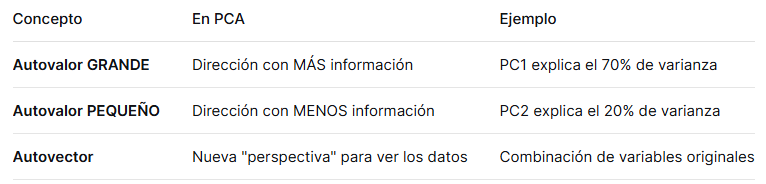

### **Pasos Simplificados del PCA**

1. **Estandarizar los datos**  
   Ajusta los datos para que tengan media 0 y varianza 1. Esto asegura que todas las variables contribuyan por igual al análisis.

2. **Calcular la matriz de covarianza**  
   Encuentra cómo las variables se relacionan entre sí (covarianza). Esto te da una idea de las direcciones principales en las que varían los datos.

3. **Encontrar autovectores y autovalores**  
   - Calcula los autovectores y autovalores de la matriz de covarianza.  
   - Los autovectores indican las direcciones principales (componentes principales), y los autovalores indican cuánta información captura cada dirección.

4. **Seleccionar los componentes principales**  
   Decide qué autovectores mantener (los más importantes, según sus autovalores) y forma con ellos el **vector de características**, que es una matriz con los autovectores seleccionados.

5. **Proyectar los datos**  
   Transforma los datos originales al nuevo espacio definido por los componentes principales. Esto reduce la dimensionalidad y simplifica el análisis.

---

$$
\boxed{\text{ACP: Estandariza, encuentra direcciones principales, selecciona las más importantes y transforma los datos.}}
$$

# Ejemplo 1

Hallando la **varianza** y **covarianza** usando el Toy ejemplo

---

## Datos dados:

| Registro | x1 | x2 |
|----------|----|----|
| 0        | 1  | 1  |
| 1        | 1  | 1  |
| 2        | 1  | 1  |
| 3        | 1  | 2  |
| 4        | 2  | 2  |

---

## Calcular la Varianza

La **varianza** mide qué tanto se dispersan los datos alrededor de su media. Se calcula con la siguiente fórmula (varianza muestral):

$
\text{Varianza} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n - 1}
$

---

### Para la variable $(x_1)$:

- **Promedio**:  
$
\bar{x}_1 = \frac{1+1+1+1+2}{5} = \frac{6}{5} = 1.2
$

- **Varianza**:  
$
\text{Var}(x_1) = \frac{(1-1.2)^2+(1-1.2)^2+(1-1.2)^2+(1-1.2)^2+(2-1.2)^2}{5-1}
$

$
\text{Var}(x_1) = \frac{(0.04+0.04+0.04+0.04+0.64)}{4} = \frac{0.8}{4} = 0.2
$

---

### Para la variable $(x_2)$:

- **Promedio**:  
$
\bar{x}_2 = \frac{1+1+1+2+2}{5} = \frac{7}{5} = 1.4
$

- **Varianza**:  
$
\text{Var}(x_2) = \frac{(1-1.4)^2+(1-1.4)^2+(1-1.4)^2+(2-1.4)^2+(2-1.4)^2}{5-1}
$

$
\text{Var}(x_2) = \frac{(0.16+0.16+0.16+0.36+0.36)}{4} = \frac{1.2}{4} = 0.3
$

---

## Calcular la Covarianza entre $(x_1)$ y $(x_2)$

La covarianza mide cómo cambian juntas dos variables respecto a sus promedios respectivos. La fórmula general es:

$
\text{Cov}(x_1,x_2) = \frac{\sum_{i=1}^{n}(x_{1i}-\bar{x}_1)(x_{2i}-\bar{x}_2)}{n - 1}
$

Cálculo paso a paso:

| x1 | x2 | (x1 - 1.2) | (x2 - 1.4) | Producto |
|----|----|------------|------------|----------|
| 1  | 1  | -0.2       | -0.4       | 0.08     |
| 1  | 1  | -0.2       | -0.4       | 0.08     |
| 1  | 1  | -0.2       | -0.4       | 0.08     |
| 1  | 2  | -0.2       | 0.6        | -0.12    |
| 2  | 2  | 0.8        | 0.6        | 0.48     |

- **Suma de productos:** $(0.08 + 0.08 + 0.08 - 0.12 + 0.48 = 0.6)$

Finalmente:

$
\text{Cov}(x_1,x_2) = \frac{0.6}{5-1} = \frac{0.6}{4} = 0.15
$

---

## Matriz de Covarianza Completa:
La matriz de covarianza muestra varianza en la diagonal y covarianzas fuera de ella:

$
\begin{bmatrix}
\text{Var}(x_1) & \text{Cov}(x_1,x_2) \\[6pt]
\text{Cov}(x_2,x_1) & \text{Var}(x_2)
\end{bmatrix}
=
\begin{bmatrix}
0.2 & 0.15 \\[6pt]
0.15 & 0.3
\end{bmatrix}
$

---

**Resultado:**  
- Varianza de $(x_1)$: **0.2**  
- Varianza de $(x_2)$: **0.3**  
- Covarianza entre $(x_1)$ y $(x_2)$: **0.15**

#Cálculo detallado de **autovalores** y **autovectores** de una Matriz

---

## **Paso 1: Matriz de covarianza dada**

La matriz de covarianza es:

$
\Sigma = \begin{bmatrix}
0.2 & 0.15\\[6pt]
0.15 & 0.3
\end{bmatrix}
$

---

## **Paso 2: Cálculo de autovalores**

Los autovalores $(\lambda)$ se obtienen resolviendo el polinomio característico de la matriz:

$
|\Sigma - \lambda I| = 0
$

Es decir:

$
\begin{vmatrix}
0.2 - \lambda & 0.15\\[6pt]
0.15 & 0.3 - \lambda
\end{vmatrix} = 0
$

Esto equivale a:

$
(0.2 - \lambda)(0.3 - \lambda) - (0.15)(0.15) = 0
$

Expandiendo la ecuación:

$
(0.06 - 0.2\lambda - 0.3\lambda + \lambda^2) - 0.0225 = 0
$

Simplificamos:

$
\lambda^2 - 0.5\lambda + 0.0375 = 0
$

Ahora resolvemos esta ecuación cuadrática con la fórmula general:

$
\lambda = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}
$

Aquí:
- $(a = 1)$
- $(b = -0.5)$
- $(c = 0.0375)$

Entonces:

$
\lambda = \frac{0.5 \pm \sqrt{(-0.5)^2 - 4(1)(0.0375)}}{2(1)}
$

Calculando dentro de la raíz:

$
= \frac{0.5 \pm \sqrt{0.25 - 0.15}}{2}
= \frac{0.5 \pm \sqrt{0.1}}{2}
= \frac{0.5 \pm 0.3162278}{2}
$

Así obtenemos los dos autovalores:

- $(\lambda_1 = \frac{0.5 + 0.3162278}{2} = 0.4081)$
- $(\lambda_2 = \frac{0.5 - 0.3162278}{2} = 0.0919)$

---

## **Paso 3: Calcular autovectores**

Para encontrar los autovectores, usamos la matriz original y resolvemos para cada autovalor la ecuación:

$
(\Sigma - \lambda I)\vec{v} = 0
$

### **Autovector para $(\lambda_1 = 0.4081)$:**

$
\begin{bmatrix}
0.2 - 0.4081 & 0.15 \\[6pt]
0.15 & 0.3 - 0.4081
\end{bmatrix}
=
\begin{bmatrix}
-0.2081 & 0.15 \\[6pt]
0.15 & -0.1081
\end{bmatrix}
*
\begin{bmatrix}
v_1 \\[6pt]
v_2
\end{bmatrix}
$

Multiplicamos por el vector $([v_1, v_2])$:

$
-0.2081 v_1 + 0.15 v_2 = 0 \quad \rightarrow \quad 0.15 v_2 = 0.2081 v_1
$

Por lo tanto:

$
\frac{v_2}{v_1} = \frac{0.2081}{0.15} = 1.3873
$

Un autovector correspondiente es:

$
\vec{v}_1 = \begin{bmatrix} 1 \\ 1.3873 \end{bmatrix}
$

Al normalizar, tenemos: $([-0.5847, -0.8112])$ (signos opuestos indican misma dirección, solo cambia orientación).


$
   \|\mathbf{v}\| = \sqrt{(-1)^2 + (-1.3873)^2} = \sqrt{1 + 1.9245} = \sqrt{2.9245} \approx 1.71
$

$
\mathbf{\hat{v}} = \begin{bmatrix} \frac{v}{\|\mathbf{v}\|} \\ \frac{v}{\|\mathbf{v}\|} \end{bmatrix}= \begin{bmatrix} \frac{-1}{1.71} \\ \frac{-1.3873}{1.71} \end{bmatrix} \approx \begin{bmatrix} -0.5848 \\ -0.8113 \end{bmatrix}
$

Portanto, o vetor normalizado é aproximadamente $ \mathbf{\hat{v}} = \begin{bmatrix} -0.5848 \\ -0.8113 \end{bmatrix} $.



---

### **Autovector para $(\lambda_2 = 0.0919)$:**

$
\begin{bmatrix}
0.2 - 0.0919 & 0.15 \\[6pt]
0.15 & 0.3 - 0.0919
\end{bmatrix}
=
\begin{bmatrix}
0.1081 & 0.15 \\[6pt]
0.15 & 0.2081
\end{bmatrix}
$

Multiplicamos por $([v_1, v_2])$:

$
0.1081 v_1 + 0.15 v_2 = 0 \quad \rightarrow \quad 0.15 v_2 = -0.1081 v_1
$

Así tenemos:

$
\frac{v_2}{v_1} = -\frac{0.1081}{0.15} = -0.7207
$

Un autovector correspondiente es:

$
\vec{v}_2 = \begin{bmatrix} 1 \\ -0.7207 \end{bmatrix}
$

---
Normalizar el autovector obtenido manualmente:

---

## **Autovector original**:

$
\vec{v} = \begin{bmatrix} 1 \\ -0.7207 \end{bmatrix}
$

## **Proceso de normalización**:

Normalizar significa obtener un vector unitario, es decir, un vector con norma (magnitud) igual a 1. La fórmula es:

$
\vec{v}_{norm} = \frac{\vec{v}}{\|\vec{v}\|}
$

Primero, calculamos la norma:

$
||\vec{v}|| = \sqrt{(1)^2 + (-0.7207)^2}
= \sqrt{1 + 0.5194}
= \sqrt{1.5194}
= 1.2326
$

Luego dividimos cada elemento por la norma:

$
\vec{v}_{norm}
= \frac{1}{1.2326}\begin{bmatrix}1 \\ -0.7207\end{bmatrix}
= \begin{bmatrix} 0.8112 \\ -0.5847 \end{bmatrix}
$

$
[-0.8112,\quad 0.5847]
$

Un cambio global de signo es aceptable y no afecta la dirección del autovector.
Este resultado coincide (en dirección) con el autovector: $([-0.8112, 0.5847])$.
---

- Los **autovalores** indican la cantidad de varianza explicada por cada dirección principal.
- Los **autovectores** muestran la dirección en la que los datos presentan mayor dispersión (direcciones principales).

---

## **Resultado final:**

| Autovalores  | Autovectores     |
|--------------|-----------------------------------|
| 0.4081       | $([-0.5847, -0.8112])$                 |
| 0.0919       | $([-0.8112,\quad 0.5847])$                |

In [ ]:
# Datos proporcionados
x1 = np.array([1, 1, 1, 1, 2])
x2 = np.array([1, 1, 1, 2, 2])

# Crear matriz de datos
datos = np.vstack((x1, x2)).T

# Calcular la matriz de covarianza
matriz_cov = np.cov(datos, rowvar=False)

# Calcular autovalores y autovectores
autovalores, autovectores = np.linalg.eig(matriz_cov)

matriz_cov, autovalores, autovectores

(array([[0.2 , 0.15],
        [0.15, 0.3 ]]),
 array([0.09188612, 0.40811388]),
 array([[-0.81124219, -0.58471028],
        [ 0.58471028, -0.81124219]]))

In [ ]:
import numpy as np
import pandas as pd

# Crear variables x1 y x2 con 5 registros
x1 = [1, 1, 1, 1, 2]
x2 = [1, 1, 1, 2, 2]

# Crear DataFrame
df = pd.DataFrame({'x1': x1, 'x2': x2})
df

,x1,x2
0,1,1
1,1,1
2,1,1
3,1,2
4,2,2


In [ ]:
# Calcular varianza de cada variable
varianza_x1 = np.var(x1, ddof=1)
varianza_x2 = np.var(x2, ddof=1)

print(varianza_x1)
print(varianza_x2)

0.2
0.3


In [ ]:
# Calcular covarianza entre x1 y x2
covarianza = np.cov(df, rowvar=False)
print(df)
print(varianza_x1)
print(varianza_x2)
print(covarianza)

   x1  x2
0   1   1
1   1   1
2   1   1
3   1   2
4   2   2
0.2
0.3
[[0.2  0.15]
 [0.15 0.3 ]]


In [ ]:
# Usando la matriz de covarianza proporcionada
cov_matrix = np.array([[0.2, 0.15], [0.15, 0.3]])

# Calcular autovalores y autovectores
autovalores, autovectores = np.linalg.eig(cov_matrix)

autovalores, autovectores

(array([0.09188612, 0.40811388]),
 array([[-0.81124219, -0.58471028],
        [ 0.58471028, -0.81124219]]))

# Análisis de Componentes Principales (PCA) Ejemplo 2

##Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

# 1. Cargar los datos
data = load_iris()
X = data.data
y = data.target
feature_names = data.feature_names

In [ ]:
# Crear un DataFrame para mejor visualización
df = pd.DataFrame(X, columns=feature_names)
df['Target'] = y
print("Datos originales:")
print(df.head(9))

Datos originales:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   
5                5.4               3.9                1.7               0.4   
6                4.6               3.4                1.4               0.3   
7                5.0               3.4                1.5               0.2   
8                4.4               2.9                1.4               0.2   

   Target  
0       0  
1       0  
2       0  
3       0  
4       0  
5       0  
6       0  
7       0  
8       0  


In [ ]:
# 2. Estandarizar los datos
# PCA es sensible a la escala de las variables, por lo que debemos estandarizarlas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nDatos estandarizados (primeras 9 filas):")
print(X_scaled[:9])


Datos estandarizados (primeras 9 filas):
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]
 [-0.53717756  1.93979142 -1.16971425 -1.05217993]
 [-1.50652052  0.78880759 -1.34022653 -1.18381211]
 [-1.02184904  0.78880759 -1.2833891  -1.3154443 ]
 [-1.74885626 -0.36217625 -1.34022653 -1.3154443 ]]


In [ ]:
# 3. Aplicar PCA
# Especificamos el número de componentes principales que queremos extraer
n_components = 2  # Reducimos a 2 dimensiones para visualización
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
print(X_pca[:9])

[[-2.26470281  0.4800266 ]
 [-2.08096115 -0.67413356]
 [-2.36422905 -0.34190802]
 [-2.29938422 -0.59739451]
 [-2.38984217  0.64683538]
 [-2.07563095  1.48917752]
 [-2.44402884  0.0476442 ]
 [-2.23284716  0.22314807]
 [-2.33464048 -1.11532768]]


## Autovalores

In [ ]:
# Autovalores (varianza explicada por cada componente)
eigenvalues = pca.explained_variance_
print("Autovalores (varianza explicada):")
print(eigenvalues)

Autovalores (varianza explicada):
[2.93808505 0.9201649 ]


## Autovectores

In [ ]:
# Autovectores (loadings - pesos factoriales)
loadings = pd.DataFrame(pca.components_, columns=feature_names, index=[f"PC{i+1}" for i in range(n_components)])
print("\nAutovectores (loadings):")
print(loadings)


Autovectores (loadings):
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
PC1           0.521066         -0.269347           0.580413          0.564857
PC2           0.377418          0.923296           0.024492          0.066942


## Ejemplo: Primer registro original

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Cargar dataset Iris original
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data

# Primer registro original
registro = np.array([[5.1, 3.5, 1.4, 0.2]])

# Estandarizar todo el conjunto
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[0]

array([-0.90068117,  1.01900435, -1.34022653, -1.3154443 ])

$PC1=(0.521066×SL)+(−0.269347×SW)+(0.580413×PL)+(0.564857×PW)$
$PC2=(0.377418×SL)+(0.923296×SW)+(0.024492×PL)+(0.066942×PW)$

In [ ]:
PC1r0=(0.521066*-0.90068117)+(-0.269347*1.01900435)+(0.580413*-1.34022653)+(0.564857*-1.3154443)
PC2r0=(0.377418*-0.90068117)+(0.923296*1.01900435)+(0.024492*-1.34022653)+(0.066942*-1.3154443)
print(PC1r0)
print(PC2r0)

-2.2647029211086602
0.4800260540151799


In [ ]:
# Datos transformados (proyección en el espacio de los componentes principales)
pca_df = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(n_components)])
print("\nDatos transformados por PCA:")
print(pca_df.head())


Datos transformados por PCA:
        PC1       PC2
0 -2.264703  0.480027
1 -2.080961 -0.674134
2 -2.364229 -0.341908
3 -2.299384 -0.597395
4 -2.389842  0.646835


## DataFrame con los resultados de PCA

In [ ]:
# Crear un DataFrame con los resultados de PCA
pca_df = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(n_components)])
pca_df['Target'] = y
print("\nDatos transformados por PCA:")
print(pca_df.head())


Datos transformados por PCA:
        PC1       PC2  Target
0 -2.264703  0.480027       0
1 -2.080961 -0.674134       0
2 -2.364229 -0.341908       0
3 -2.299384 -0.597395       0
4 -2.389842  0.646835       0


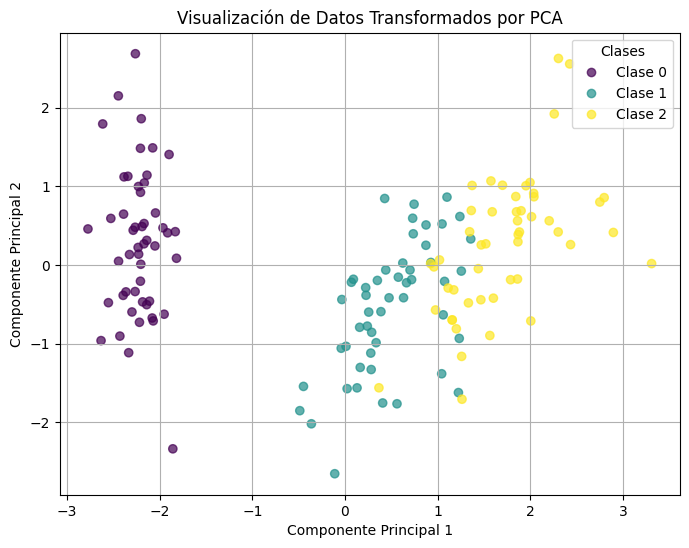

In [ ]:
# Visualización de los datos transformados
plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_df["PC1"], pca_df["PC2"], c=pca_df["Target"], cmap="viridis", alpha=0.7)
plt.title("Visualización de Datos Transformados por PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(handles=scatter.legend_elements()[0], labels=[f"Clase {i}" for i in np.unique(y)], title="Clases")
plt.grid(True)
plt.show()

In [ ]:
# 7. Matriz de componentes principales (loadings)
# La matriz de loadings muestra cómo cada variable original contribuye a cada componente principal
loadings = pd.DataFrame(pca.components_, columns=feature_names, index=[f"PC{i+1}" for i in range(n_components)])
print("\nMatriz de Loadings (Contribución de cada variable a los componentes principales):")
print(loadings)


Matriz de Loadings (Contribución de cada variable a los componentes principales):
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
PC1           0.521066         -0.269347           0.580413          0.564857
PC2           0.377418          0.923296           0.024492          0.066942


In [ ]:
# Ordenar loadings por componente
for i in range(n_components):
    print(f"Variables más importantes para PC{i+1}:")
    sorted_loadings = loadings.iloc[i].abs().sort_values(ascending=False)
    print(sorted_loadings)

Variables más importantes para PC1:
petal length (cm)    0.580413
petal width (cm)     0.564857
sepal length (cm)    0.521066
sepal width (cm)     0.269347
Name: PC1, dtype: float64
Variables más importantes para PC2:
sepal width (cm)     0.923296
sepal length (cm)    0.377418
petal width (cm)     0.066942
petal length (cm)    0.024492
Name: PC2, dtype: float64


In [ ]:
import numpy as np

cov_matrix = np.cov(X_scaled, rowvar=False)  # rowvar=False indica que las columnas son variables
print("Matriz de Covarianza:")
print(cov_matrix)

Matriz de Covarianza:
[[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


# Visualización

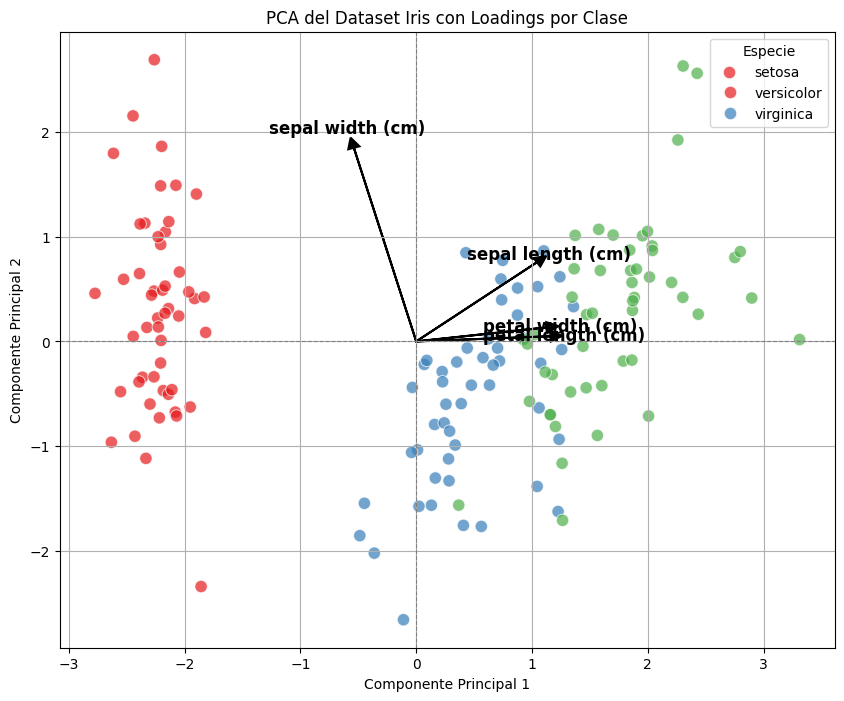

In [ ]:
# Repitiendo el código tras reinicio del entorno
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Cargar dataset Iris
iris = load_iris()
X = iris.data
feature_names = iris.feature_names

# Estandarizar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA con 2 componentes principales
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# DataFrame para visualización
df_pc = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Loadings (autovectores)
loadings = pd.DataFrame(pca.components_.T,
                        columns=['PC1', 'PC2'],
                        index=feature_names)

# Scatter plot PC1 vs PC2 con loadings y colores según clase de iris
import matplotlib.pyplot as plt
import seaborn as sns

# Añadir la clase (target) al DataFrame
df_pc['species'] = iris.target

# Mapa de colores para especies
species_names = iris.target_names

# Gráfico con colores por clase
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='species', palette='Set1', data=df_pc, alpha=0.7, s=80)

# Dibujar los vectores (loadings)
for i, feature in enumerate(feature_names):
    plt.arrow(0, 0, loadings.iloc[i, 0]*2, loadings.iloc[i, 1]*2,
              color='black', head_width=0.1, head_length=0.1, linewidth=1.5)
    plt.text(loadings.iloc[i, 0]*2.2, loadings.iloc[i, 1]*2.2, feature,
             color='black', ha='center', va='center', fontsize=12, fontweight='bold')

# Configuración visual
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.axhline(0, color='grey', linewidth=0.8, linestyle='--')
plt.axvline(0, color='grey', linewidth=0.8, linestyle='--')
plt.grid(True)
plt.title('PCA del Dataset Iris con Loadings por Clase')
plt.legend(title='Especie', labels=species_names)
plt.show()

#Modelo

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# Características (PC1 y PC2)
X = pca_df[['PC1', 'PC2']]

# Etiquetas (clases de flores)
y = iris.target

In [ ]:
# Dividir los datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Modelo SVM (Máquinas de Soporte Vectorial)
from sklearn.svm import SVC
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


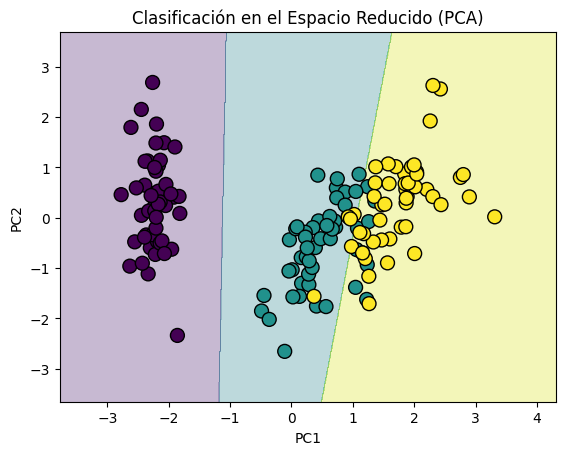

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Crear una malla para graficar la frontera de decisión
x_min, x_max = X['PC1'].min() - 1, X['PC1'].max() + 1
y_min, y_max = X['PC2'].min() - 1, X['PC2'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Predecir la clase para cada punto en la malla
Z = svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Graficar la frontera de decisión
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
plt.scatter(X['PC1'], X['PC2'], c=y, edgecolor='k', s=100, cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clasificación en el Espacio Reducido (PCA)')
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# Realizar predicciones en el conjunto de prueba
y_pred = svm.predict(X_test)

# Matriz de Confusión
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred))

# Reporte de Clasificación
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

# Precisión del Modelo
print("\nPrecisión del Modelo:")
print(accuracy_score(y_test, y_pred))

Matriz de Confusión:
[[10  0  0]
 [ 0  7  2]
 [ 0  1 10]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.88      0.78      0.82         9
           2       0.83      0.91      0.87        11

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30


Precisión del Modelo:
0.9


### **Referencias**

https://rpubs.com/cristina_gil/pca

https://www.miraltabank.com/analisis-de-componentes-principales/